# Transformer DGA Fault Classification — Dataset Validity & Signal Analysis

**A2 Option 2 — Preliminary Notebook**

## Purpose

This notebook is the first stage of the project. Its purpose is to determine whether the supplied company-provided synthetic DGA dataset contains a meaningful, learnable relationship between DGA measurements and the `fault_by_rogers` target.

We will **not** perform extensive hyperparameter tuning here.

Instead, we will:

1. Load and audit the dataset.
2. Document the dataset structure and target.
3. Identify potential target leakage.
4. Examine whether DGA variables differ across fault classes.
5. Establish a majority-class baseline.
6. Test simple and nonlinear classifiers using stratified cross-validation.
7. Repeat evaluation with permuted labels as a control experiment.
8. Decide whether the dataset provides enough evidence to proceed to the main modelling stage.

> **Confidentiality:** The underlying industrial source data and company identity must not be disclosed. This notebook uses only the synthetic dataset supplied for academic use.

In [2]:
# 2. Environment setup

import sys
import subprocess
import importlib.util

required = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "openpyxl": "openpyxl",
    "xgboost": "xgboost",
}

missing = [pip_name for module, pip_name in required.items()
           if importlib.util.find_spec(module) is None]

if missing:
    print("Installing missing packages:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

print("Environment ready.")

Environment ready.


In [3]:
# 3. Imports and reproducibility

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    make_scorer,
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Random state:", RANDOM_STATE)

Random state: 42


## 4. Load the dataset

### Expected file

The notebook assumes the uploaded file is:

`dummy_dga_dataset.xlsx`

If using Google Colab, upload the file to the Colab session or change `DATA_PATH` to the location of the uploaded file.

In [5]:
DATA_PATH = "C:\\Users\\srian\\Documents\\GitHub\\32513 31005 Advanced Data Analytics Algorithms, Machine Learning\\Data\\dummy_dga_dataset.xlsx"

df = pd.read_excel(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully.
Shape: (300, 23)


,row_id,asset,ts_H2,H2,C2H2,C2H4,C2H6,CH4,CO,CO2,...,ts_CH4,ts_CO,ts_CO2,R_C2H2_C2H4,R_CH4_H2,R_C2H4_C2H6,abnormal,triggers,status,fault_by_rogers
0,1,TX_A,2025-01-01 00:00:00,31.390939,0.882090,14.181881,4.206888,13.688683,599.963626,7332.511459,...,2025-01-01 00:00:00,2025-01-01 00:00:00,2025-01-01 00:00:00,0.062198,0.436071,3.371110,False,NaN,Normal,Non-determinable
1,2,TX_B,2025-01-01 01:00:00,35.341884,0.507179,12.612538,6.345830,59.938383,557.168722,7240.401074,...,2025-01-01 01:00:00,2025-01-01 01:00:00,2025-01-01 01:00:00,0.040212,1.695959,1.987532,False,NaN,Normal,Thermal Fault
2,3,TX_C,2025-01-01 02:00:00,65.635357,0.002433,24.096744,7.336242,38.569814,594.269670,9993.446821,...,2025-01-01 02:00:00,2025-01-01 02:00:00,2025-01-01 02:00:00,0.000101,0.587638,3.284617,False,NaN,Normal,Partial Discharge
3,4,TX_B,2025-01-01 03:00:00,12.796451,0.537190,24.218719,16.563508,31.730099,776.015100,8341.712289,...,2025-01-01 03:00:00,2025-01-01 03:00:00,2025-01-01 03:00:00,0.022181,2.479602,1.462173,False,NaN,Normal,Normal
4,5,TX_B,2025-01-01 04:00:00,48.779920,0.435549,22.021012,15.318398,33.244361,665.254346,8202.173810,...,2025-01-01 04:00:00,2025-01-01 04:00:00,2025-01-01 04:00:00,0.019779,0.681517,1.437553,False,NaN,Normal,Non-determinable


In [6]:
# 5. Basic dataset audit

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("\nColumn names:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))

print("\nDuplicate rows:", df.duplicated().sum())

Rows: 300
Columns: 23

Column names:
01. row_id
02. asset
03. ts_H2
04. H2
05. C2H2
06. C2H4
07. C2H6
08. CH4
09. CO
10. CO2
11. ts_C2H2
12. ts_C2H4
13. ts_C2H6
14. ts_CH4
15. ts_CO
16. ts_CO2
17. R_C2H2_C2H4
18. R_CH4_H2
19. R_C2H4_C2H6
20. abnormal
21. triggers
22. status
23. fault_by_rogers

Data types:


,dtype
row_id,int64
asset,object
ts_H2,datetime64[ns]
H2,float64
C2H2,float64
C2H4,float64
C2H6,float64
CH4,float64
CO,float64
CO2,float64



Missing values:


,missing
triggers,119
row_id,0
ts_C2H6,0
status,0
abnormal,0
R_C2H4_C2H6,0
R_CH4_H2,0
R_C2H2_C2H4,0
ts_CO2,0
ts_CO,0



Duplicate rows: 0


## 5.1 Target distribution

The main target is `fault_by_rogers`.

We will inspect the class distribution before modelling because accuracy alone can be misleading when class sizes differ.

,count,percentage
fault_by_rogers,,
Normal,87,29.00
Partial Discharge,76,25.33
Thermal Fault,74,24.67
Non-determinable,63,21.00


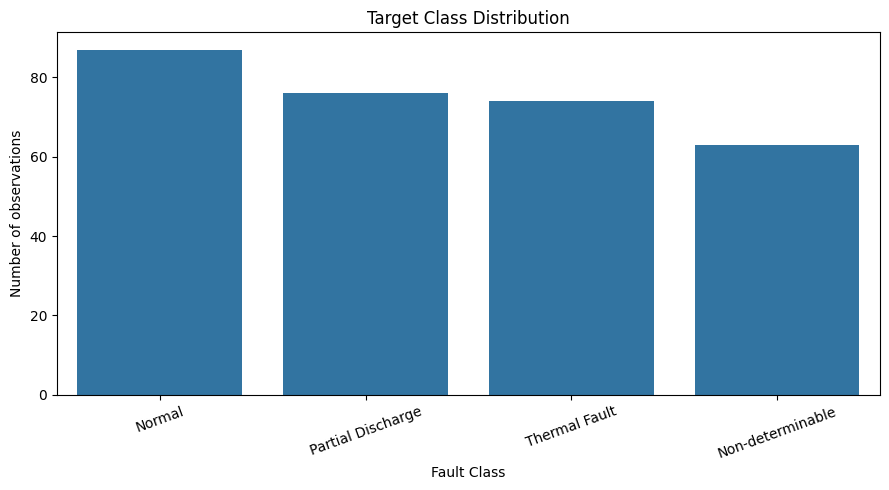

In [7]:
TARGET = "fault_by_rogers"

if TARGET not in df.columns:
    raise KeyError(
        f"'{TARGET}' was not found. Available columns are:\n{df.columns.tolist()}"
    )

target_counts = df[TARGET].value_counts(dropna=False)
target_pct = df[TARGET].value_counts(normalize=True, dropna=False).mul(100).round(2)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_pct
})

display(target_summary)

plt.figure(figsize=(9, 5))
sns.countplot(data=df, x=TARGET, order=target_counts.index)
plt.title("Target Class Distribution")
plt.xlabel("Fault Class")
plt.ylabel("Number of observations")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()